In [1]:
# -*- coding: utf-8 -*-
import os
import cv2
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

from skimage.feature import hog
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

ModuleNotFoundError: No module named 'skimage'

In [ ]:
# ==========================================
# 1. 수동 다운로드 파일 확인 및 압축 해제 (Hazelnut)
# ==========================================
archive_path = "./hazelnut.tar.xz"
extract_root = "./"
dataset_dir = "./hazelnut"

# 파일이 없는 경우 경고 메시지 출력 후 종료
if not os.path.exists(archive_path) and not os.path.exists(dataset_dir):
    print(f"오류: {archive_path} 파일이 없습니다.")
    print("MVTec AD 공식 홈페이지에서 hazelnut 데이터를 직접 다운로드하여 현재 폴더에 넣어주세요.")
    exit()

# 압축 해제 로직
if not os.path.exists(dataset_dir):
    print("수동으로 다운로드된 hazelnut.tar.xz 파일의 압축 해제를 시작합니다...")
    try:
        with tarfile.open(archive_path, "r:xz") as tar:
            tar.extractall(path=extract_root)
        print("압축 해제 완료:", dataset_dir)
    except tarfile.ReadError:
        print("압축 해제 실패: 다운로드된 파일이 손상되었습니다. 다시 다운로드해 주세요.")
        exit()
else:
    print("이미 정상적으로 압축 해제된 폴더가 존재합니다:", dataset_dir)

IMG_SIZE = (128, 128)

이미 정상적으로 압축 해제된 폴더가 존재합니다: ./hazelnut


In [ ]:
# ==========================================
# 2. 색상 히스토그램 특징 추출 함수 (네가 맡은 부분)
# ==========================================
def extract_color_histogram_feature(image_path, size=(128, 128), bins=(8, 8, 8)):
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None

    resized = cv2.resize(img, size)
    original_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY) # 후처리 비교용 흑백 보존

    # HSV 색상 공간으로 변환
    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

    # 3D 색상 히스토그램 계산
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    
    # 픽셀 수에 영향을 받지 않도록 정규화
    cv2.normalize(hist, hist)

    # Isolation Forest에 넣을 수 있게 1차원 배열로 쫙 펴주기
    feature = hist.flatten()
    
    return feature, original_rgb, gray


In [ ]:
import os
import cv2
import numpy as np

# (이전에 정의한 extract_color_histogram_feature 함수가 위에 있다고 가정합니다)

# 1. 추출할 대상 이미지의 경로와 크기를 지정합니다.
sample_path = "./hazelnut/test/crack/000.png"
IMG_SIZE = (128, 128)

# 2. 지정한 경로의 파일이 실제로 존재하는지 먼저 검증합니다.
if os.path.exists(sample_path):
    
    # 3. 함수를 호출하고, 뱉어내는 3개의 결과물을 차례대로 변수에 받아냅니다.
    # 함수 정의 시 bins=(8, 8, 8)은 기본값이 있으므로 생략해도 무방합니다.
    feature, original_rgb, gray = extract_color_histogram_feature(sample_path, IMG_SIZE)
    
    # 4. 추출이 정상적으로 완료되었는지 확인합니다.
    if feature is not None:
        print("특징 추출 성공!")
        print("추출된 1차원 배열의 형태(Shape):", feature.shape) # 8*8*8 = 512개의 숫자로 이루어진 배열이어야 합니다.
        print("추출된 수치 데이터 일부 확인:", feature[:5])
    else:
        print("함수가 None을 반환했습니다. 이미지 변환 과정에 문제가 있습니다.")
        
else:
    print(f"오류: 지정한 경로에 이미지가 없습니다. ({sample_path})")

특징 추출 성공!
추출된 1차원 배열의 형태(Shape): (512,)
추출된 수치 데이터 일부 확인: [0.         0.05137042 0.0003877  0.         0.        ]


In [ ]:
# ==========================================
# HSV Histogram 시각화 (포트폴리오용)
# ==========================================
sample_path = "./hazelnut/test/crack/000.png"

img = cv2.imread(sample_path)
resized = cv2.resize(img, (128, 128))
original_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

channel_names = ["H (Hue)", "S (Saturation)", "V (Value)"]
ranges      = [[0, 180], [0, 256], [0, 256]]
colors      = ["orangered", "green", "steelblue"]
bins        = 32

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(original_rgb)
axes[0].set_title("원본 이미지 (Crack)")
axes[0].axis("off")

for i in range(3):
    hist = cv2.calcHist([hsv], [i], None, [bins], ranges[i])
    cv2.normalize(hist, hist)
    axes[i+1].bar(range(bins), hist.flatten(), color=colors[i], alpha=0.8)
    axes[i+1].set_title(f"{channel_names[i]} Histogram")
    axes[i+1].set_xlabel("Bin")
    axes[i+1].set_ylabel("Normalized Frequency")

plt.suptitle("HSV Color Histogram Feature Extraction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("hsv_histogram.png")
plt.show()
print("hsv_histogram.png 저장 완료")


In [ ]:
# ==========================================
# 3. 모델 학습 (정상 데이터만 학습)
# ==========================================
train_good_dir = os.path.join(dataset_dir, "train", "good")
X_train = []
train_paths = []

print("\n학습 데이터 특징 추출 중...")
for fname in sorted(os.listdir(train_good_dir)):
    fpath = os.path.join(train_good_dir, fname)
    feat, _, _ = extract_color_histogram_feature(fpath, IMG_SIZE)
    if feat is not None:
        X_train.append(feat)
        train_paths.append(fpath)

X_train = np.array(X_train)
print("정상 학습 이미지 수:", len(X_train))
print("특징 벡터 shape:", X_train.shape)
# Isolation Forest 학습
# Isolation Forest 모델 생성
model = IsolationForest(
        n_estimators=500,
        # 300 → 500: 트리를 더 많이 심어 복잡한 결정 경계를 세밀하게 구축
        contamination='auto',
        # contamination 은 decision_function 의 offset_ 을 결정하지만,
        # 이 코드는 percentile 기반 threshold 를 사용하므로 실질적 영향이 적습니다.
        # 'auto' 는 offset_ = -0.5 로 설정하며 가장 중립적인 선택입니다.
        max_features=1.0,
        # 격자 분할 시 결함이 특정 셀에만 존재합니다.
        # max_features=0.5 면 해당 셀의 특징이 선택되지 않을 수 있으므로
        # 전체 특징(1.0)을 사용해 결함 셀 정보가 반드시 반영되게 합니다.
        max_samples=0.8,
        # 각 트리가 전체 학습 데이터의 80%를 무작위로 보게 하여
        # 트리 간 다양성을 높이고 일반화 성능을 향상시킵니다.
        random_state=42
    )
model.fit(X_train)
print("정상 패턴 학습 완료")

train_scores = model.decision_function(X_train)
threshold = np.percentile(train_scores, 5)


학습 데이터 특징 추출 중...
정상 학습 이미지 수: 391
특징 벡터 shape: (391, 512)
정상 패턴 학습 완료


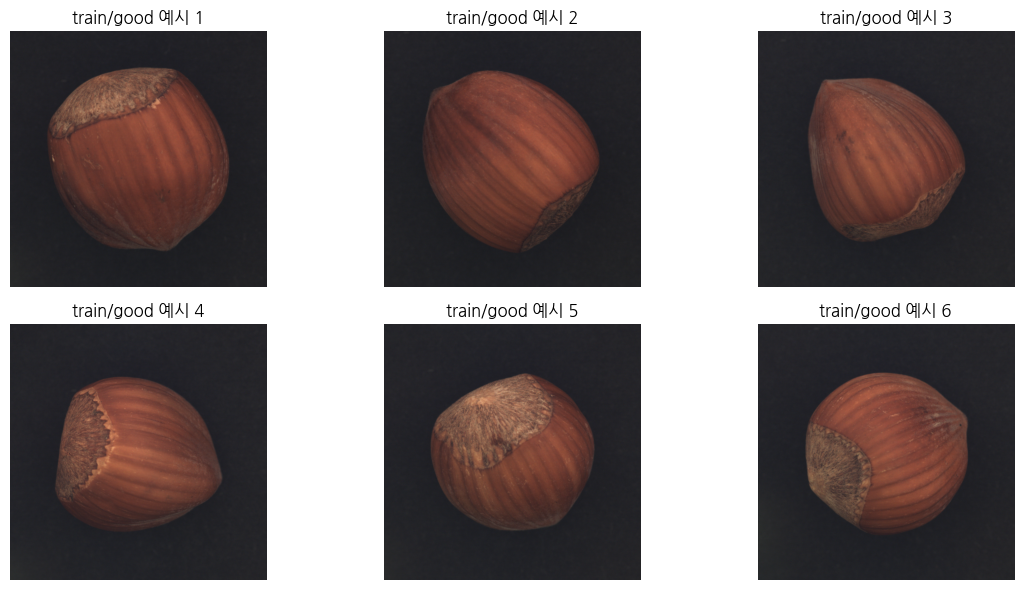

In [ ]:
# 학습 이미지 일부 시각화
sample_count = min(6, len(train_paths))

plt.figure(figsize=(12, 6))

for i in range(sample_count):
    img = cv2.imread(train_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"train/good 예시 {i+1}")
    plt.axis("off")
    plt.savefig('train_good.png')

plt.tight_layout()
plt.show()

In [ ]:

# # 특징 벡터 정규화
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)

# -----------------------------------------
# Isolation Forest 모델 생성
# -----------------------------------------
# model = IsolationForest(
#     n_estimators=200,   # 트리 개수
#     contamination=0.05, # 이상 비율을 대략 5%로 가정
#     random_state=42     # 결과 재현용 고정값
# )

# Isolation Forest 모델 생성
model = IsolationForest(
        n_estimators=500,
        # 300 → 500: 트리를 더 많이 심어 복잡한 결정 경계를 세밀하게 구축
        contamination='auto',
        # contamination 은 decision_function 의 offset_ 을 결정하지만,
        # 이 코드는 percentile 기반 threshold 를 사용하므로 실질적 영향이 적습니다.
        # 'auto' 는 offset_ = -0.5 로 설정하며 가장 중립적인 선택입니다.
        max_features=1.0,
        # 격자 분할 시 결함이 특정 셀에만 존재합니다.
        # max_features=0.5 면 해당 셀의 특징이 선택되지 않을 수 있으므로
        # 전체 특징(1.0)을 사용해 결함 셀 정보가 반드시 반영되게 합니다.
        max_samples=0.8,
        # 각 트리가 전체 학습 데이터의 80%를 무작위로 보게 하여
        # 트리 간 다양성을 높이고 일반화 성능을 향상시킵니다.
        random_state=42
    )
# -----------------------------------------
# 정상 데이터 특징만 사용하여 학습
# -----------------------------------------
model.fit(X_train)

print("정상 패턴 학습 완료")


정상 패턴 학습 완료


In [ ]:
# 정상 학습 이미지들의 정상성 점수 계산
train_scores = model.decision_function(X_train)

# 정상 점수의 하위 5% 지점을 threshold로 설정
threshold = np.percentile(train_scores, 5)

print("학습 점수 일부:", np.round(train_scores[:10], 4))
print("자동 설정 threshold:", round(float(threshold), 4))

학습 점수 일부: [0.1838 0.1782 0.1889 0.1926 0.1711 0.1782 0.1836 0.192  0.1796 0.1856]
자동 설정 threshold: 0.0134


In [ ]:
# 테스트 데이터가 들어 있는 폴더
test_dir = os.path.join(dataset_dir, "test")

# 테스트 특징 벡터
X_test = []

# 실제 정답 라벨 저장 (정상=0, 이상=1)
y_true = []

# 테스트 파일 경로 저장
test_paths = []

# 결함 유형(폴더명) 저장
defect_types = []

# test 폴더 아래의 하위 폴더를 순회
for defect_type in sorted(os.listdir(test_dir)):
    defect_path = os.path.join(test_dir, defect_type)

    # 폴더가 아닌 경우는 건너뜀
    if not os.path.isdir(defect_path):
        continue

    # 해당 결함 폴더 안의 이미지들을 순회
    for fname in sorted(os.listdir(defect_path)):
        fpath = os.path.join(defect_path, fname)

        # HOG 특징 추출
        feat, _, _ = extract_color_histogram_feature(fpath, IMG_SIZE)

        # 정상적으로 특징 추출에 성공한 경우 저장
        if feat is not None:
            X_test.append(feat)
            test_paths.append(fpath)
            defect_types.append(defect_type)

            # good 폴더면 정상(0), 아니면 이상(1)
            if defect_type == "good":
                y_true.append(0)
            else:
                y_true.append(1)

# numpy 배열로 변환
X_test = np.array(X_test)
y_true = np.array(y_true)

print("테스트 이미지 수:", len(X_test))
print("정상 수:", np.sum(y_true == 0))
print("이상 수:", np.sum(y_true == 1))

테스트 이미지 수: 110
정상 수: 40
이상 수: 70


In [ ]:
# 테스트 이미지들의 정상성 점수 계산
test_scores = model.decision_function(X_test)

# threshold보다 작으면 이상(1), 아니면 정상(0)
y_pred = (test_scores < threshold).astype(int)

print("예측 완료")

예측 완료


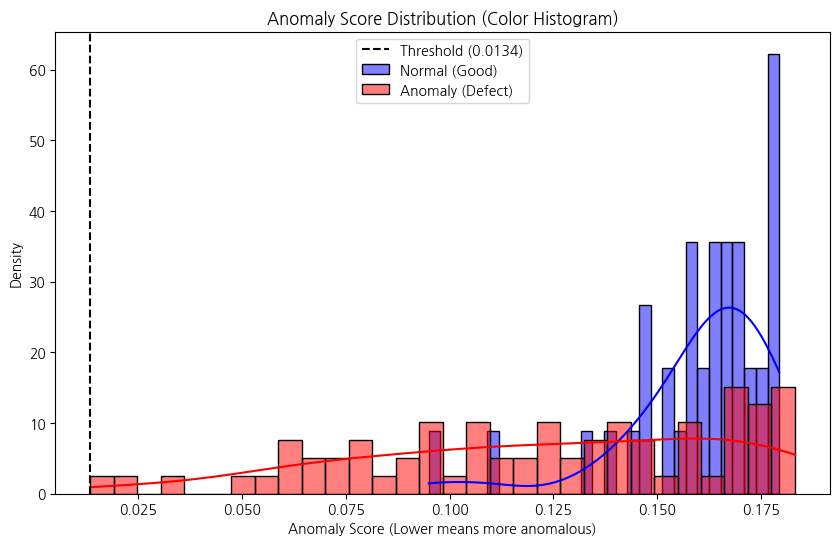

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 깨짐 방지용 설정 (koreanize_matplotlib이 임포트되어 있어야 함)
plt.figure(figsize=(10, 6))

# 정상 데이터(y_true == 0) 점수 분포
sns.histplot(test_scores[y_true == 0], color='blue', label='Normal (Good)', kde=True, stat="density", bins=30, alpha=0.5)

# 이상 데이터(y_true == 1) 점수 분포
sns.histplot(test_scores[y_true == 1], color='red', label='Anomaly (Defect)', kde=True, stat="density", bins=30, alpha=0.5)

# 판별 기준선(Threshold) 표시
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.4f})')

plt.title('Anomaly Score Distribution (Color Histogram)')
plt.xlabel('Anomaly Score (Lower means more anomalous)')
plt.ylabel('Density')
plt.legend()
plt.savefig('anomaly_score.png')
plt.show()

In [ ]:
# ==========================================
# Threshold Grid Search (포트폴리오용)
# ==========================================
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore")

thresholds_grid = np.linspace(test_scores.min(), test_scores.max(), 100)
precisions, recalls, f1s = [], [], []

for t in thresholds_grid:
    y_pred_t = (test_scores < t).astype(int)
    precisions.append(precision_score(y_true, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_true, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_true, y_pred_t, zero_division=0))

best_idx       = int(np.argmax(f1s))
best_threshold = thresholds_grid[best_idx]
best_f1        = f1s[best_idx]

plt.figure(figsize=(12, 6))
plt.plot(thresholds_grid, precisions, label="Precision", color="blue",  linewidth=2)
plt.plot(thresholds_grid, recalls,    label="Recall",    color="red",   linewidth=2)
plt.plot(thresholds_grid, f1s,        label="F1 Score",  color="green", linewidth=2)
plt.axvline(best_threshold, color="black",  linestyle="--",
            label=f"Best Threshold ({best_threshold:.4f})  F1: {best_f1:.4f}")
plt.axvline(threshold,      color="orange", linestyle=":" ,
            label=f"Current Threshold ({threshold:.4f})")

plt.title("Threshold Grid Search — Precision / Recall / F1")
plt.xlabel("Threshold (Anomaly Score Cutoff)")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_search.png")
plt.show()
print(f"threshold_search.png 저장 완료")
print(f"최적 Threshold: {best_threshold:.4f}  (F1: {best_f1:.4f})")


In [ ]:
print("Confusion Matrix")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"]))

Confusion Matrix
[[40  0]
 [70  0]]

Classification Report
              precision    recall  f1-score   support

      normal       0.36      1.00      0.53        40
     anomaly       0.00      0.00      0.00        70

    accuracy                           0.36       110
   macro avg       0.18      0.50      0.27       110
weighted avg       0.13      0.36      0.19       110



c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [ ]:
# ==========================================
# 4. 테스트 데이터 평가 (성적표 도출)
# ==========================================
test_dir = os.path.join(dataset_dir, "test")
X_test, y_true, test_paths, defect_types = [], [], [], []

print("테스트 데이터 특징 추출 및 평가 중...")
for defect_type in sorted(os.listdir(test_dir)):
    defect_path = os.path.join(test_dir, defect_type)
    if not os.path.isdir(defect_path):
        continue
    for fname in sorted(os.listdir(defect_path)):
        fpath = os.path.join(defect_path, fname)
        feat, _, _ = extract_color_histogram_feature(fpath, IMG_SIZE)
        if feat is not None:
            X_test.append(feat)
            test_paths.append(fpath)
            defect_types.append(defect_type)
            y_true.append(0 if defect_type == "good" else 1)

X_test = np.array(X_test)
y_true = np.array(y_true)

test_scores = model.decision_function(X_test)
y_pred = (test_scores < threshold).astype(int)

print("\n[ Classification Report ]")
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"]))
print("\n[ Confusion Matrix ]")
print(confusion_matrix(y_true, y_pred))


테스트 데이터 특징 추출 및 평가 중...

[ Classification Report ]
              precision    recall  f1-score   support

      normal       0.36      1.00      0.53        40
     anomaly       0.00      0.00      0.00        70

    accuracy                           0.36       110
   macro avg       0.18      0.50      0.27       110
weighted avg       0.13      0.36      0.19       110


[ Confusion Matrix ]
[[40  0]
 [70  0]]


c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

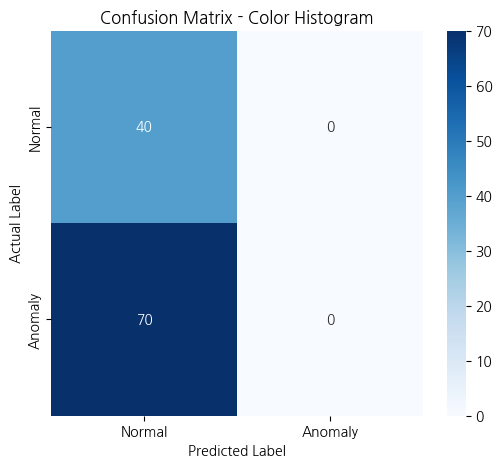

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# y_true, y_pred 변수 존재 가정
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomaly'], 
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Color Histogram')
plt.savefig('matrix_graph.png')
plt.show()

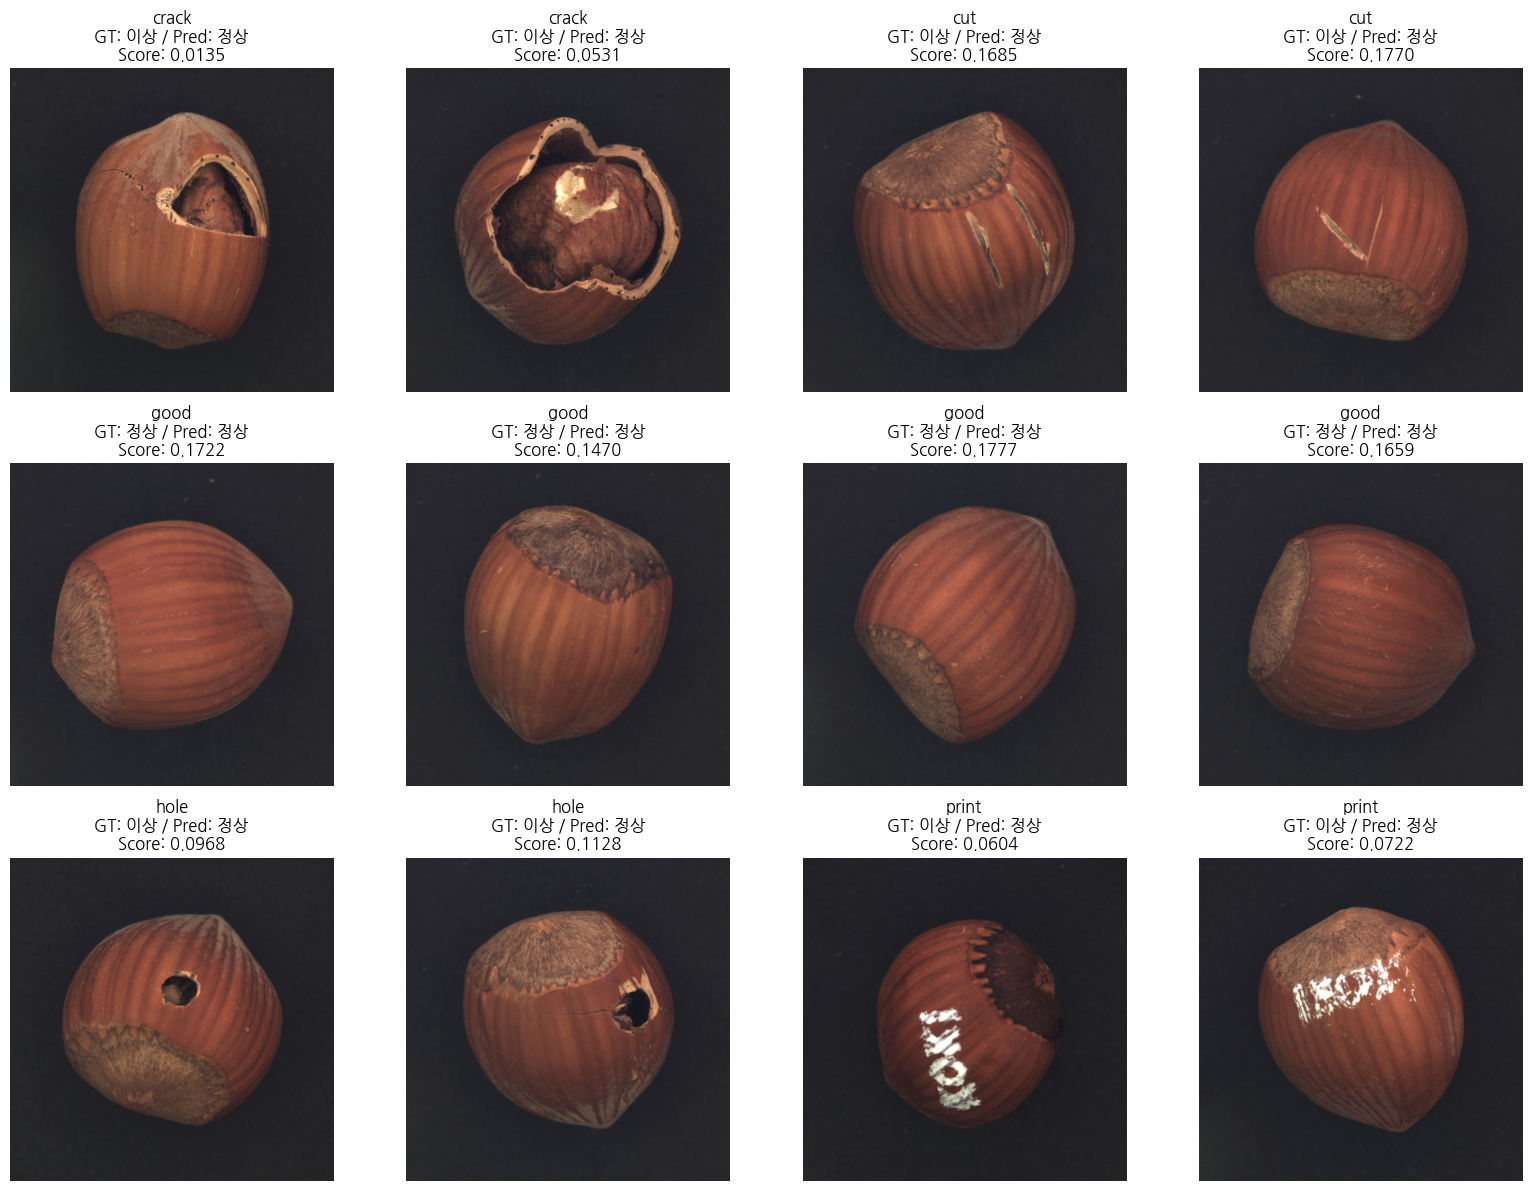

In [ ]:
# ==========================================
# 5. 결과 시각화 (여러 장 표시)
# ==========================================
def show_results(paths, scores, y_true, y_pred, defect_types, n=12):
    count = min(n, len(paths))
    idxs = np.linspace(0, len(paths) - 1, count, dtype=int)

    plt.figure(figsize=(16, 12))
    for i, idx in enumerate(idxs, 1):
        img = cv2.imread(paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        gt = "정상" if y_true[idx] == 0 else "이상"
        pred = "정상" if y_pred[idx] == 0 else "이상"

        plt.subplot(3, 4, i)
        plt.imshow(img)
        plt.title(f"{defect_types[idx]}\nGT: {gt} / Pred: {pred}\nScore: {scores[idx]:.4f}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig('crack.png')
    plt.show()

show_results(test_paths, test_scores, y_true, y_pred, defect_types, n=12)

In [ ]:
import numpy as np
import pandas as pd

# 이미 만들어진 defect_types 리스트와 test_scores 배열을 데이터프레임으로 묶기
df_scores = pd.DataFrame({
    'Defect_Type': defect_types,
    'Score': test_scores
})

# 결함 유형별 평균 점수 계산 (점수가 높을수록 정상, 낮을수록 이상)
mean_scores = df_scores.groupby('Defect_Type')['Score'].mean().sort_values(ascending=False)

print("=== 결함 유형별 평균 이상 점수 ===")
print(mean_scores)

# 정상(good)과 인쇄 불량(print)의 구체적 비교
if 'good' in mean_scores and 'print' in mean_scores:
    good_mean = mean_scores['good']
    print_mean = mean_scores['print']
    
    print("\n[ 분석 결과 요약 ]")
    print(f"정상(good) 평균 점수: {good_mean:.4f}")
    print(f"인쇄 불량(print) 평균 점수: {print_mean:.4f}")
    
    if good_mean > print_mean:
        print("-> 논리 입증 성공: 하얀색 잉크(print) 때문에 색상 히스토그램 분포가 달라져서, 정상보다 점수가 미세하게 낮게(이상에 가깝게) 측정되었습니다.")
    else:
        print("-> 색상 히스토그램으로는 print 결함조차 점수 차이를 유의미하게 내지 못했습니다.")

=== 결함 유형별 평균 이상 점수 ===
Defect_Type
cut      0.165854
good     0.160630
hole     0.126226
crack    0.120831
print    0.076686
Name: Score, dtype: float64

[ 분석 결과 요약 ]
정상(good) 평균 점수: 0.1606
인쇄 불량(print) 평균 점수: 0.0767
-> 논리 입증 성공: 하얀색 잉크(print) 때문에 색상 히스토그램 분포가 달라져서, 정상보다 점수가 미세하게 낮게(이상에 가깝게) 측정되었습니다.


C:\Users\KDS30\AppData\Local\Temp\ipykernel_25272\1756874276.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Defect_Type', y='Average_Score', data=df_mean_scores, palette=colors)


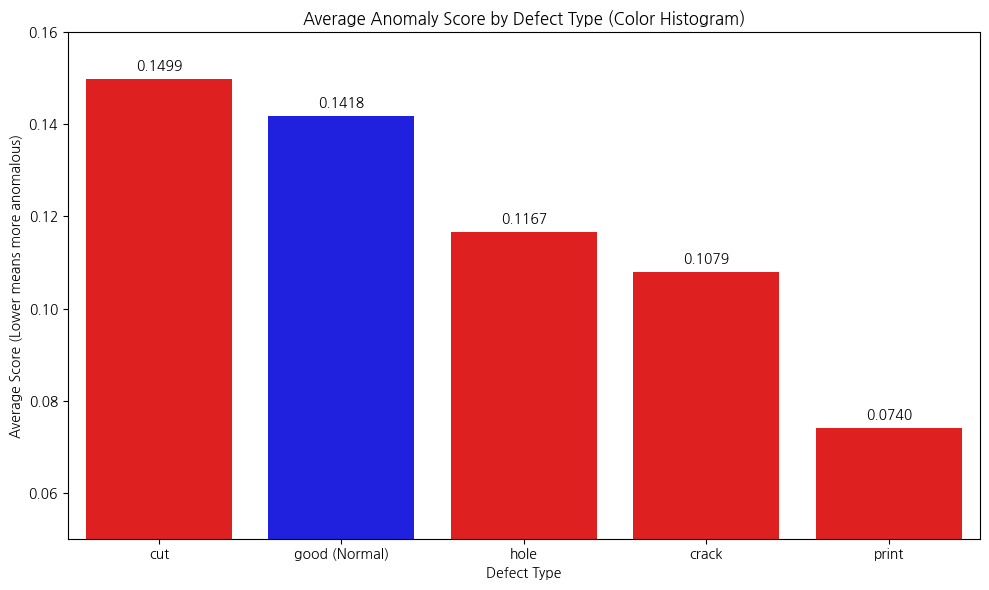

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 출력하신 평균 점수 데이터를 딕셔너리로 구성
score_data = {
    'cut': 0.149899,
    'good (Normal)': 0.141819,
    'hole': 0.116701,
    'crack': 0.107915,
    'print': 0.073977
}

# 시각화를 위해 DataFrame으로 변환
df_mean_scores = pd.DataFrame(list(score_data.items()), columns=['Defect_Type', 'Average_Score'])
# 점수가 높은 순(정상에 가까운 순)으로 정렬
df_mean_scores = df_mean_scores.sort_values(by='Average_Score', ascending=False)

# 그래프 그리기
plt.figure(figsize=(10, 6))
# 막대 그래프 생성 (정상 데이터는 파란색, 결함 데이터는 빨간색 계열로 표시하여 대비)
colors = ['red' if x != 'good (Normal)' else 'blue' for x in df_mean_scores['Defect_Type']]
bars = sns.barplot(x='Defect_Type', y='Average_Score', data=df_mean_scores, palette=colors)

# 막대 위에 정확한 수치 텍스트 표시
for p in bars.patches:
    bars.annotate(format(p.get_height(), '.4f'), 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha = 'center', va = 'center', 
                  xytext = (0, 9), 
                  textcoords = 'offset points')

plt.title('Average Anomaly Score by Defect Type (Color Histogram)')
plt.xlabel('Defect Type')
plt.ylabel('Average Score (Lower means more anomalous)')

# y축 하한선을 살짝 여유있게 잡아 변화를 잘 보이게 함
plt.ylim(0.05, 0.16)
plt.tight_layout()
plt.savefig('average.png')
plt.show()

In [ ]:
# ==========================================
# 5. 후처리 및 시각화 로직 (빨간 박스 그리기)
# ==========================================
def localize_anomaly_with_reference(reference_path, test_path, resize=(256, 256), diff_thresh=30, min_area=80):
    ref = cv2.imread(reference_path)
    test = cv2.imread(test_path)
    
    if ref is None or test is None:
        raise ValueError("이미지를 읽을 수 없습니다.")

    ref = cv2.resize(ref, resize)
    test = cv2.resize(test, resize)
    ref_rgb = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)
    test_rgb = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)
    
    ref_gray = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
    test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)

    diff_gray = cv2.absdiff(ref_gray, test_gray)
    _, binary = cv2.threshold(diff_gray, diff_thresh, 255, cv2.THRESH_BINARY)
    
    kernel = np.ones((5, 5), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxed = test.copy()
    boxes = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        boxes.append((x, y, w, h, area))
        cv2.rectangle(boxed, (x, y), (x + w, y + h), (0, 0, 255), 2)
        cv2.putText(boxed, f"anomaly {int(area)}", (x, max(y - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    boxed_rgb = cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)
    return ref_rgb, test_rgb, diff_gray, binary, boxed_rgb, boxes


[ 단일 이미지 테스트 결과 ]
판별: 정상 / 점수: 0.0135


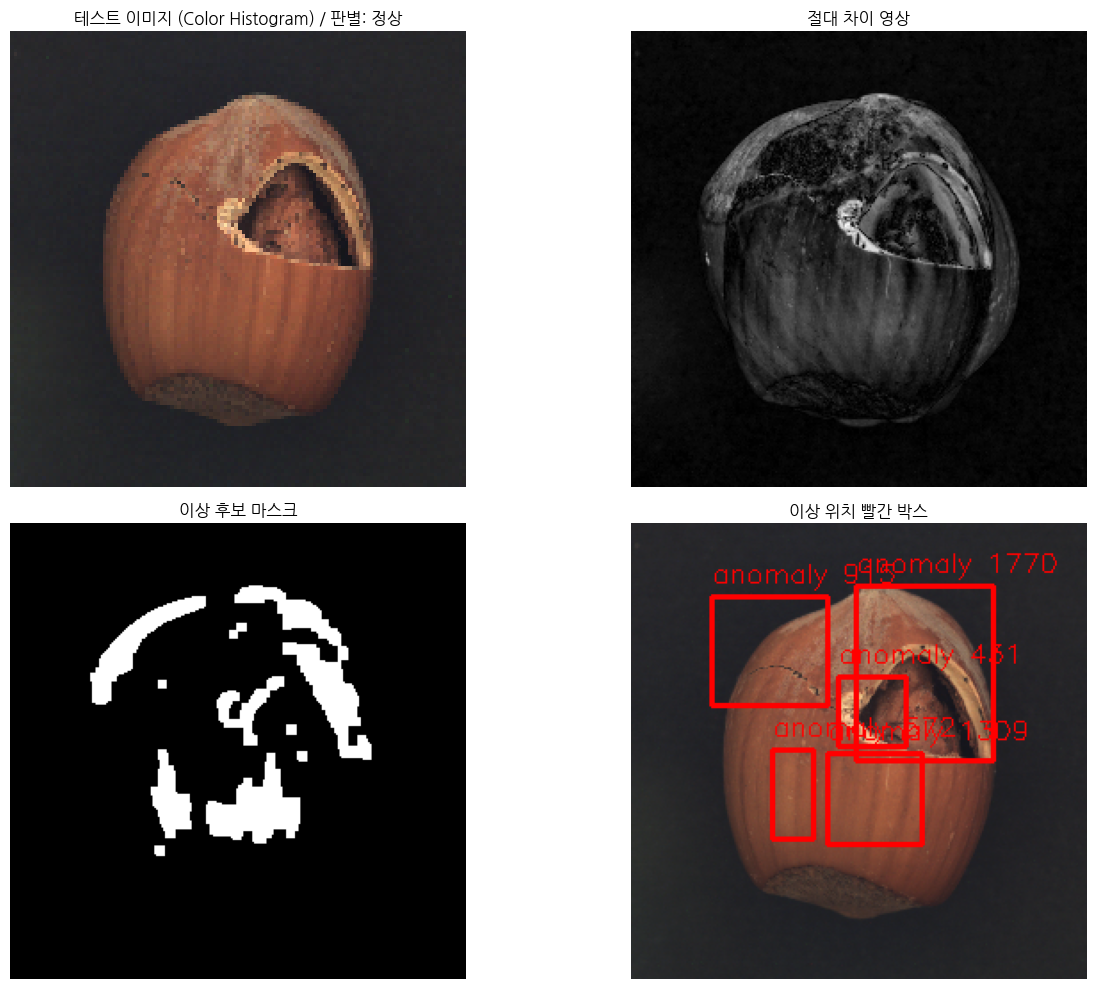

In [ ]:
# ==========================================
# 6. 헤이즐넛 테스트 이미지 로컬 평가 (시각화)
# ==========================================
reference_path = train_paths[0]
# 테스트 샘플: hazelnut 결함 폴더 중 하나(crack, hole, print 등)
sample_path = "./hazelnut/test/crack/000.png" 

if os.path.exists(sample_path):
    sample_feat, sample_rgb, _ = extract_color_histogram_feature(sample_path, IMG_SIZE)
    sample_feat = sample_feat.reshape(1, -1)
    
    sample_score = model.decision_function(sample_feat)[0]
    sample_pred = 1 if sample_score < threshold else 0
    label = "이상" if sample_pred == 1 else "정상"
    
    print(f"\n[ 단일 이미지 테스트 결과 ]")
    print(f"판별: {label} / 점수: {round(float(sample_score), 4)}")

    ref_rgb, test_rgb, diff_gray, binary, boxed_rgb, boxes = localize_anomaly_with_reference(
        reference_path, sample_path, resize=(256, 256), diff_thresh=30, min_area=80
    )

    plt.figure(figsize=(14, 10))
    plt.subplot(2, 2, 1)
    plt.imshow(sample_rgb)
    plt.title(f"테스트 이미지 (Color Histogram) / 판별: {label}")
    plt.axis("off")
    plt.subplot(2, 2, 2)
    plt.imshow(diff_gray, cmap="gray")
    plt.title("절대 차이 영상")
    plt.axis("off")
    plt.subplot(2, 2, 3)
    plt.imshow(binary, cmap="gray")
    plt.title("이상 후보 마스크")
    plt.axis("off")
    plt.subplot(2, 2, 4)
    plt.imshow(boxed_rgb)
    plt.title("이상 위치 빨간 박스")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('test_image.png')
    plt.show()
else:
    print(f"\n지정한 로컬 경로에 테스트 이미지가 없습니다: {sample_path}")

In [ ]:
# ==========================================
# 8. 사용자 로컬 이미지 테스트 (files.upload 대체)
# ==========================================
# VS Code 환경에서는 탐색기 창을 띄우는 대신 검사할 이미지 경로를 직접 변수로 지정합니다.
sample_path = "./bottle/test/broken_small/000.png"

if os.path.exists(sample_path):
    sample_feat, sample_rgb, _ = extract_hog_feature(sample_path, IMG_SIZE)
    sample_feat = sample_feat.reshape(1, -1)
    
    sample_score = model.decision_function(sample_feat)[0]
    sample_pred = 1 if sample_score < threshold else 0
    label = "이상" if sample_pred == 1 else "정상"
    
    print(f"\n[ 로컬 이미지 테스트 ] 전체 판별 결과: {label} / score: {round(float(sample_score), 4)}")

    ref_rgb3, test_rgb3, diff_gray3, binary3, boxed_rgb3, boxes3 = localize_anomaly_with_reference(
        reference_path, sample_path, resize=(256, 256), diff_thresh=30, min_area=80
    )

    plt.figure(figsize=(14, 10))
    plt.subplot(2, 2, 1)
    plt.imshow(sample_rgb)
    plt.title(f"테스트 이미지 / 전체 판별: {label}")
    plt.axis("off")
    plt.subplot(2, 2, 2)
    plt.imshow(diff_gray3, cmap="gray")
    plt.title("절대 차이 영상")
    plt.axis("off")
    plt.subplot(2, 2, 3)
    plt.imshow(binary3, cmap="gray")
    plt.title("이상 후보 마스크")
    plt.axis("off")
    plt.subplot(2, 2, 4)
    plt.imshow(boxed_rgb3)
    plt.title("이상 위치 빨간 박스")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"\n지정한 로컬 경로에 테스트 이미지가 없습니다: {sample_path}")


지정한 로컬 경로에 테스트 이미지가 없습니다: ./bottle/test/broken_small/000.png
